## Reprojecting a shape

This example draws a square defined in geographic coordinates (PlateCarree) and reprojects it onto a different coordinate system. Because the reprojection is handled by Cartopy, straight edges in one projection become curves in another — a useful illustration of how projections distort shapes.

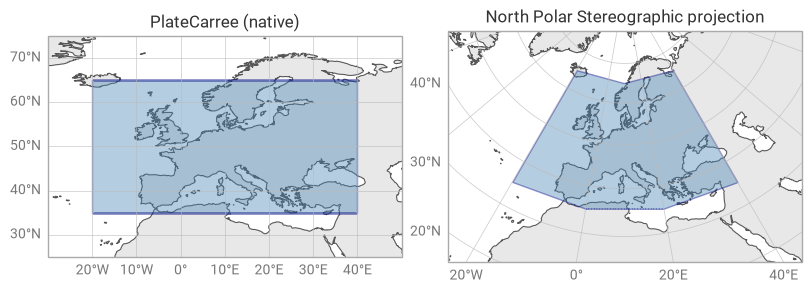

In [1]:
import earthkit.plots as ekp
import cartopy.crs as ccrs
from shapely.geometry import box

# A square in geographic (lon/lat) space
square = box(-20, 35, 40, 65)

fig = ekp.Figure(rows=1, columns=2)

# Left: the square in its native PlateCarree projection
left = fig.add_map(domain=[-30, 50, 25, 75], crs=ccrs.PlateCarree())
left.land()
left.coastlines()
left.gridlines()
left.ax.add_geometries(
    [square],
    crs=ccrs.PlateCarree(),
    facecolor="steelblue",
    edgecolor="navy",
    alpha=0.4,
)
left.title("PlateCarree (native)")

# Right: the same square reprojected onto a North Polar Stereographic CRS
right = fig.add_map(
    domain=[-30, 50, 25, 75],
    crs=ccrs.NorthPolarStereo(central_longitude=10),
)
right.land()
right.coastlines()
right.gridlines()
right.ax.add_geometries(
    [square],
    crs=ccrs.PlateCarree(),
    facecolor="steelblue",
    edgecolor="navy",
    alpha=0.4,
)
right.title("{crs} projection")

fig.show()